In [89]:
# KT AICE Associate 자격인증 실전 연습문제: UCI Heart Disease
#
# 이 연습문제는 'UCI Heart Disease' 데이터셋을 사용하여
# 데이터 분석, 전처리 및 머신러닝 이진 분류 모델 학습·평가 능력을 평가합니다.
#
# [유의사항]
# • 각 문항의 답안코드는 반드시 '# 여기에 답안코드를 작성하세요'로 표시된 cell에 작성해야 합니다.
# • 문제에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.
# • 문제에서 명시적으로 요구하는 함수나 방법을 사용해야 합니다.
#
# 이 문제는 공개 심장질환 데이터를 이용하여 **심장질환 유무를 예측하는 이진 분류 모델**을 만드는 과정입니다.
# - 데이터 파일: `heart_fixed.csv`
# - 원본 행/열: 920행, 16열
# - 실제 타겟 변수: `num`
# - `num` 원본 값: 0~4
# - 이 문제에서는 `0 → 0`, `1~4 → 1`로 변환해 사용합니다.
# - 기존 초안의 `target`, `thalach`을 실제 컬럼명인 `num`, `thalch`로 수정했습니다.

In [90]:
# --- 문제 1. 라이브러리 불러오기 ---
#
# 데이터 처리를 위해 `pandas`를 `pd`, `numpy`를 `np`로 불러오세요.  
# 시각화를 위해 `seaborn`을 `sns`, `matplotlib.pyplot`을 `plt`로 불러오세요.


In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [92]:
# --- 문제 2. 데이터 로드와 실제 구조 확인 ---
#
# `heart_fixed.csv`를 읽어 `df`에 저장하세요.
#
# 1. 데이터의 행과 열 개수를 확인하세요.
# 2. 전체 컬럼명을 출력하세요.
# 3. 실제 타겟 컬럼명을 문자열로 `답안02`에 저장하세요.


In [93]:
df = pd.read_csv("heart_fixed.csv", dtype=str)

print(df.shape)
print(df.columns)
답안02 = 'num'


(920, 16)
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [94]:
# --- 문제 3. `?`를 결측치로 변환 ---
#
# 원본 데이터의 결측값은 문자열 `?`로 표시되어 있습니다.
#
# 1. 데이터 전체에 있는 `?` 개수를 먼저 확인하세요.
# 2. 모든 `?`를 `np.nan`으로 바꾸세요.
# 3. 변환 후 전체 결측치 개수를 정수형으로 `답안03`에 저장하세요.


In [95]:
question_cnt = (df == '?').sum().sum()
print("물음표 개수:", question_cnt)

df = df.replace('?', np.nan)
답안03 = int(df.isna().sum().sum())
print("결측치 개수:", 답안03)


물음표 개수: 1759
결측치 개수: 1759


In [96]:
# --- 문제 4. 결측 행 제거 ---
#
# 결측치가 하나라도 포함된 행을 모두 삭제하고 결과를 다시 `df`에 저장하세요.  
# 인덱스도 0부터 다시 정리하세요.
#
# 처리 후 행 개수를 정수형으로 `답안04`에 저장하세요.


In [97]:
df = df.dropna()
df = df.reset_index(drop=True)
len(df)
답안04 = 920


In [98]:
# --- 문제 5. 데이터 타입 변환 ---
#
# 다음 컬럼은 수치형으로 변환하세요.
#
# `age`, `trestbps`, `chol`, `thalch`, `oldpeak`, `ca`, `num`
#
# 다음 컬럼은 `object` 타입으로 변환하세요.
#
# `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`
#
# 변환 후 전체 데이터 타입을 출력하세요.


In [99]:
cols1 = ['age','trestbps','chol','thalch','oldpeak','ca','num']

df[cols1] = df[cols1].astype('float')

cols2 = ['sex','dataset','cp','fbs','restecg','exang','slope','thal']

df[cols2] = df[cols2].astype('object')

df.dtypes

id           object
age         float64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num         float64
dtype: object

In [100]:
# --- 문제 6. 타겟 `num` 이진화 ---
#
# `num`이 0이면 0, 1 이상이면 1이 되도록 이진화하고 다시 `df['num']`에 저장하세요.
#
# 변환 후 클래스별 행 개수를 `{클래스: 개수}` 형태의 딕셔너리로 `답안06`에 저장하세요.


In [101]:
df.loc[df['num'] >= 1, 'num'] = 1

답안06 = df['num'].value_counts().sort_index().to_dict()


In [102]:
# --- 문제 7. 실제 컬럼을 이용한 기술통계 ---
#
# 최대 심박수 컬럼의 실제 이름은 `thalch`입니다.  
# `thalch`의 1사분위수(Q1)를 계산하고 `답안07`에 저장하세요.


In [103]:
답안07 = df['thalch'].quantile(0.25)
print("thalch Q1:", 답안07)


thalch Q1: 132.5


In [104]:
# --- 문제 8. 흉통 유형과 심장질환의 관계 ---
#
# 1. `sns.countplot()`으로 `cp`별 `num` 분포를 그리세요. `hue='num'`을 사용하세요.
# 2. `pd.crosstab()`으로 `cp`와 `num`의 교차표를 만드세요.
# 3. 심장질환 양성(`num=1`) 행이 가장 많은 `cp` 값을 `답안08`에 저장하세요.


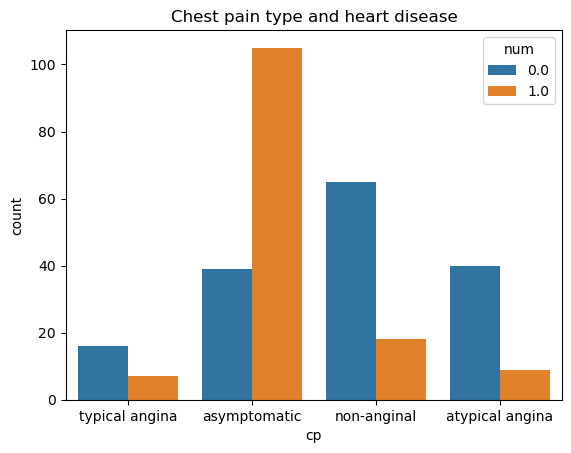

num              0.0  1.0
cp                       
asymptomatic      39  105
atypical angina   40    9
non-anginal       65   18
typical angina    16    7


In [105]:
plt.figure()
sns.countplot(data=df, x='cp', hue='num')
plt.title('Chest pain type and heart disease')
plt.show()

cp_table = pd.crosstab(df['cp'],df['num'])
print(cp_table)
답안08 = df[df['num'] == 1]['cp'].mode()[0]


In [106]:
# --- 문제 9. 피처와 레이블 분리 ---
#
# 1. `num`을 레이블 `y`로 저장하세요.
# 2. `id`와 `num`을 제외한 나머지 컬럼을 피처 `X`로 저장하세요.
# 3. `X`의 `(행 수, 열 수)`를 튜플로 `답안09`에 저장하세요.


In [107]:
y = df['num']
X = df.drop(['id','num'],axis=1)

답안09 = X.shape


In [108]:
# --- 문제 10. 범주형 변수 원-핫 인코딩 ---
#
# `X`에서 `object` 타입인 컬럼명을 직접 찾으세요.  
# 해당 컬럼을 `pd.get_dummies()`로 원-핫 인코딩하고 결과를 `X_encoded`에 저장하세요.
#
# - `drop_first=True`
# - `dtype=int`
#
# 인코딩 후 전체 컬럼 개수를 `답안10`에 저장하세요.


In [109]:
obj_cols = X.select_dtypes(include='object').columns

X_encoded = pd.get_dummies(X,columns=obj_cols,drop_first=True,dtype=int)
답안10 = X_encoded.shape[1]


In [110]:
# --- 문제 11. 훈련/검증 데이터 분할 ---
#
# `train_test_split()`을 사용하여 `X_encoded`와 `y`를 훈련 80%, 검증 20%로 분리하세요.
#
# - `random_state=42`
# - `stratify=y`
#
# 훈련과 검증 데이터의 행 개수를 딕셔너리로 `답안11`에 저장하세요.  
# 예: `{'train': 100, 'valid': 20}`


In [111]:
from sklearn.model_selection import train_test_split

X_train,X_valid,y_train,y_valid = train_test_split(
    X_encoded,y,test_size=0.2,random_state=42,stratify=y
)

답안11 = {'train':len(X_train),'valid':len(X_valid)}

In [112]:
# --- 문제 12. 수치형 피처 표준화 ---
#
# 다음 수치형 컬럼에 `StandardScaler`를 적용하세요.
#
# `age`, `trestbps`, `chol`, `thalch`, `oldpeak`, `ca`
#
# - 훈련 데이터에는 `fit_transform()`
# - 검증 데이터에는 `transform()`
#
# 스케일링 후 훈련 데이터의 `age` 평균을 소수점 넷째 자리까지 반올림하여 `답안12`에 저장하세요.


In [113]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['age','trestbps','chol','thalch','oldpeak','ca']
scaler = StandardScaler()

X_train = X_train.copy()
X_valid = X_valid.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_valid[scale_cols] = scaler.transform(X_valid[scale_cols])

답안12 = round(X_train['age'].mean(),4)


In [114]:
# --- 문제 13. 로지스틱 회귀 학습과 평가 ---
#
# `LogisticRegression` 모델을 `lr_model`로 생성하고 훈련하세요.
#
# - `max_iter=1000`
# - `random_state=42`
#
# 검증 데이터의 예측값을 `lr_pred`에 저장하고 F1 Score를 계산하세요.  
# F1 Score를 소수점 넷째 자리까지 반올림하여 `답안13`에 저장하세요.


In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix

lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_valid)
lr_f1 = f1_score(y_valid,lr_pred)
답안13 = round(lr_f1,4)

In [116]:
# --- 문제 14. 랜덤 포레스트와 모델 비교 ---
#
# `RandomForestClassifier`를 `rf_model`로 생성하고 훈련하세요.
#
# - `n_estimators=120`
# - `max_depth=6`
# - `random_state=42`
#
# 검증 데이터의 F1 Score를 계산하고, 문제 13의 로지스틱 회귀와 비교하세요.  
# F1 Score가 더 높은 모델명을 `LogisticRegression` 또는 `RandomForest` 문자열로 `답안14`에 저장하세요.


In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=120,max_depth=6,random_state=42)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_valid)
rf_f1 = f1_score(y_valid,rf_pred)

print(lr_f1)
print(rf_f1)

답안14 = 'LogisticRegression'

0.8076923076923077
0.7843137254901961
